In [ ]:
#1. process all the repeats 
error analysis (error propgation, uncertainty analysis)

# 2 find all band gaps (any more possiblity of extension work?)
#possibility 1: calculate bandgap, find the correpsonding materials.
#

# record observation 

# ppt rough draft ( figure out how the control unit works , and p-n junction)



In [23]:
#nothing connected
import time

# Lists to store data
standard_voltages = []
standard_currents = []

# Define sweep parameters
v_start = 0.0
v_stop = 5.0
v_step = 0.1

v = v_start
while v <= v_stop:
    # 1. Set voltage
    cmd = f'<S{v:.2f}>'
    ser.write(cmd.encode())
    ser.readline()  # read acknowledgement

    # 2. Allow voltage to stabilise
    time.sleep(0.1)

    # 3. Read LED voltage (A1)
    ser.write(b'<V2>')
    v_led = ser.readline().decode().strip()
    V = float(v_led.split()[1])

    # 4. Read current
    ser.write(b'<I1>')
    i_led = ser.readline().decode().strip()
    I = float(i_led.split()[1])

    # 5. Store data
    standard_voltages.append(V)
    standard_currents.append(I)

    v += v_step

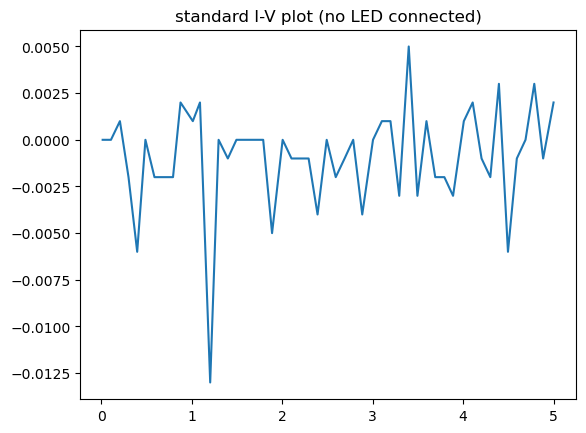

In [24]:
plt.plot(np.array(standard_voltages),np.array(standard_currents))
plt.title('standard I-V plot (no LED connected)')
plt.show()

In [28]:
pip install pyserial

Note: you may need to restart the kernel to use updated packages.


In [1]:
import serial
import serial.tools.list_ports
import time
%pylab inline
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
import csv
from datetime import datetime



%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [57]:
ports = serial.tools.list_ports.comports()

for p in ports:
    print(p.device)
print (len(ports), 'ports found')

/dev/cu.debug-console
/dev/cu.Bluetooth-Incoming-Port
/dev/cu.usbmodem2101
3 ports found


In [58]:
ser = serial.Serial('/dev/cu.usbmodem2101', baudrate=9600, timeout=2)

for _ in range(3):
    print(ser.readline().decode("utf-8"))
    

writestring = '<S0.00>'
bytestowrite = writestring.encode()
ser.write(bytestowrite)

7

In [59]:
response = ser.readline()
print(response.decode('utf-8'))

In [57]:
## test on delayed time

### The green LED was selected for the variable study because its intermediate band gap produces a well defined I–V characteristic with a sufficiently wide quasi linear region. This makes it sensitive to experimental parameters such as delay time while remaining electrically stable, allowing systematic comparison.

In [6]:
import time
import numpy as np
import matplotlib.pyplot as plt
import csv
from datetime import datetime




In [14]:
def run_green_led_iv_sweep(
    ser,
    v_start=0.0,
    v_stop=5.0,
    v_step=0.1,
    V_split=1.7
):
    """
    Run I–V sweep for Green LED with user-defined delay time.
    """

    # Ask user for delay time
    delay_time = float(input("Enter delay time in seconds (e.g. 0.01): "))

    green_voltages = []
    green_currents = []

    v = v_start
    while v <= v_stop:
        # 1. Set voltage
        cmd = f'<S{v:.2f}>'
        ser.write(cmd.encode())
        ser.readline()

        # 2. Stabilisation delay
        time.sleep(delay_time)

        # 3. Read LED voltage
        ser.write(b'<V2>')
        v_led = ser.readline().decode().strip()
        V = float(v_led.split()[1])

        # 4. Read current
        ser.write(b'<I1>')
        i_led = ser.readline().decode().strip()
        I = float(i_led.split()[1])

        # 5. Store data
        green_voltages.append(V)
        green_currents.append(I)

        v += v_step

    # Convert to numpy arrays
    V = np.array(green_voltages)
    I = np.array(green_currents)

    # Split regions
    mask_low = V < V_split
    mask_high = V > V_split

    V_low, I_low = V[mask_low], I[mask_low]
    V_high, I_high = V[mask_high], I[mask_high]

    # Linear fits
    m_low, c_low = np.polyfit(V_low, I_low, 1)
    m_high, c_high = np.polyfit(V_high, I_high, 1)

    # Plot
    plt.figure()
    plt.plot(V, I, 'o', label='Green LED data')

    V_fit_low = np.linspace(V_low.min(), V_low.max(), 100)
    V_fit_high = np.linspace(V_high.min(), V_high.max(), 100)

    plt.plot(V_fit_low, m_low * V_fit_low + c_low, '--', label='Linear fit (V < 1.7 V)')
    plt.plot(V_fit_high, m_high * V_fit_high + c_high, '--', label='Linear fit (V > 1.7 V)')

    plt.axvline(V_split, color='grey', linestyle=':', label='~ band gap')

    R_high = 1000 / m_high  # ohms
    textstr = (
        f"Above 1.7 V fit:\n"
        f"slope = {m_high:.3f} mA/V\n"
        f"R ≈ {R_high:.1f} Ω"
    )

    plt.text(
        0.05, 0.5, textstr,
        transform=plt.gca().transAxes,
        fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    plt.xlabel('Voltage / V')
    plt.ylabel('Current / mA')
    plt.title('I–V characteristic of Green LED')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return V, I, m_low, m_high

Enter delay time in seconds (e.g. 0.01): 0.03


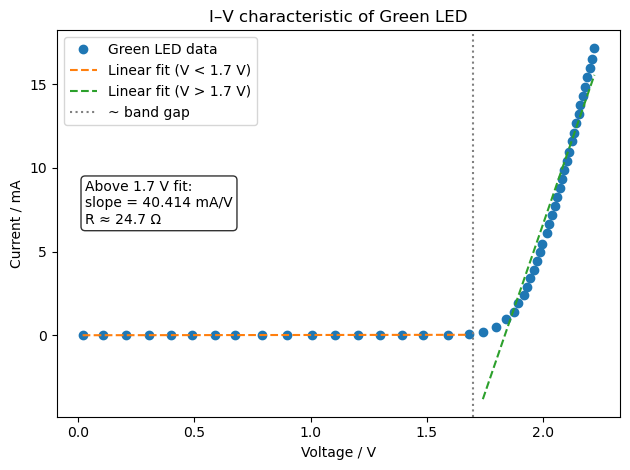

In [15]:
V_green, I_green, m_low, m_high = run_green_led_iv_sweep(ser)


In [21]:
def run_led_iv_sweep(
    ser,
    V_split=1.7,
    led_label="Green LED",
    delay=0.3
):
    """
    Run I–V sweep for an LED with user-defined step voltage.
    Stabilisation delay is fixed.
    """

    # User input: experimental variable
    step = float(input("Enter step voltage (V): "))

    voltages, currents = [], []
    v_start, v_stop = 0.0, 5.0
    v = v_start

    # Voltage sweep
    while v <= v_stop:
        ser.write(f'<S{v:.2f}>'.encode())
        ser.readline()

        time.sleep(delay)

        ser.write(b'<V2>')
        V = float(ser.readline().decode().split()[1])

        ser.write(b'<I1>')
        I = float(ser.readline().decode().split()[1])

        voltages.append(V)
        currents.append(I)

        v += step

    # Convert to numpy arrays
    V = np.array(voltages)
    I = np.array(currents)

    # Split regions
    mask_low = V < V_split
    mask_high = V > V_split

    # Linear fits
    (m_low, c_low), (m_high, c_high) = (
        np.polyfit(V[mask_low], I[mask_low], 1),
        np.polyfit(V[mask_high], I[mask_high], 1)
    )

    R_high = 1000 / m_high  # ohms

    # Plot
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

    plt.plot(V, I, 'o', label=f'{led_label} data')

    for V_seg, m, c, label in [
        (V[mask_low], m_low, c_low, 'Linear fit (V < split)'),
        (V[mask_high], m_high, c_high, 'Linear fit (V > split)')
    ]:
        V_fit = np.linspace(V_seg.min(), V_seg.max(), 100)
        plt.plot(V_fit, m * V_fit + c, '--', linewidth=2.5, label=label)

    plt.axvline(V_split, linestyle=':', linewidth=2.5, label='~ band gap')

    plt.text(
        0.02, 0.75,
        f"Above {V_split:.2f} V fit:\n"
        f"slope = {m_high:.3f} mA/V\n"
        f"R ≈ {R_high:.1f} Ω",
        transform=ax.transAxes,
        fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    plt.title(f'I–V plot of {led_label}', fontsize=20, fontweight='bold')
    plt.xlabel('Voltage / V', fontsize=18, fontweight='bold')
    plt.ylabel('Current / mA', fontsize=18, fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return V, I, m_low, m_high, R_high

Enter step voltage (V): 1


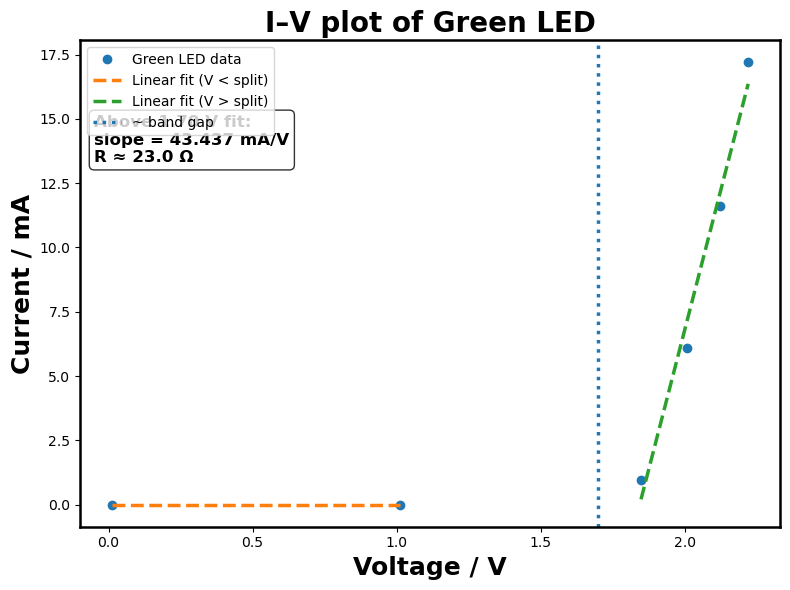

In [22]:
V, I, m_low, m_high, R = run_led_iv_sweep(ser)

In [43]:
def run_resistor_iv_sweep(
    ser,
    v_start=0.0,
    v_stop=5.0,
    v_step=0.1,
    delay=0.1
):
    """
    Run repeated I–V sweeps for a standard resistor.
    """

    repeats = int(input("Enter number of repeats: "))

    for run in range(1, repeats + 1):

        ready = input(f"Repeat {run}: Ready to start? (y/n): ").strip().lower()
        if ready != "y":
            print("Measurement aborted.")
            break

        resistor_voltages = []
        resistor_currents = []

        v = v_start
        while v <= v_stop:
            ser.write(f'<S{v:.2f}>'.encode())
            ser.readline()

            time.sleep(delay)

            ser.write(b'<V2>')
            V = float(ser.readline().decode().split()[1])

            ser.write(b'<I1>')
            I = float(ser.readline().decode().split()[1])

            resistor_voltages.append(V)
            resistor_currents.append(I)

            v += v_step

        V_arr = np.array(resistor_voltages)
        I_arr = np.array(resistor_currents)

        m, c = np.polyfit(V_arr, I_arr, 1)
        R = 1000 / m

        # Plot
        plt.figure()
        plt.plot(V_arr, I_arr, 'o-', label='Resistor data')
        plt.text(
            0.05, 0.95,
            f"R ≈ {R:.2f} Ω",
            transform=plt.gca().transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )
        plt.xlabel('Voltage / V')
        plt.ylabel('Current / mA')
        plt.title(f'Standard resistor I–V plot (run {run})')
        plt.tight_layout()
        plt.show()

        # Save CSV
        filename = f"resistor_IV_run{run}.csv"
        with open(filename, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(["Voltage (V)", "Current (mA)"])
            for V, I in zip(resistor_voltages, resistor_currents):
                writer.writerow([V, I])

        print(f"Data successfully saved to {filename}\n")

Enter number of repeats: 5
Repeat 1: Ready to start? (y/n): y


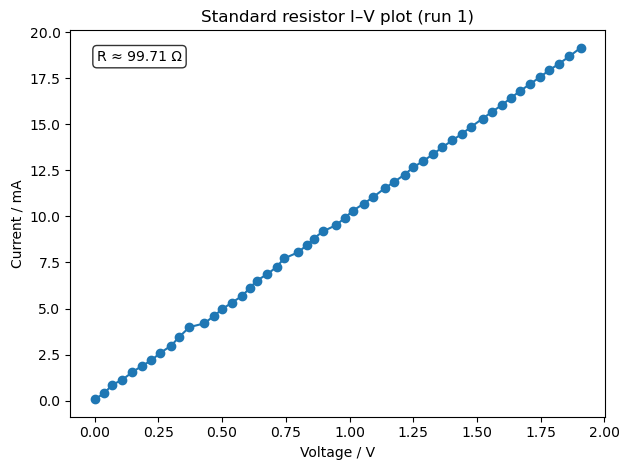

Data successfully saved to resistor_IV_run1.csv

Repeat 2: Ready to start? (y/n): y


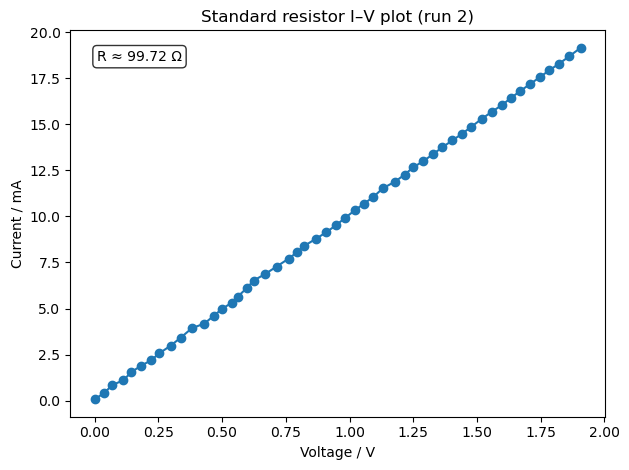

Data successfully saved to resistor_IV_run2.csv



KeyboardInterrupt: Interrupted by user

In [44]:
run_resistor_iv_sweep(ser)

In [7]:
def run_color_led_iv_sweep(
    ser,
    V_split,
    filename="color_IV_2.csv",
    v_start=0.0,
    v_stop=5.0,
    v_step=0.1,
    delay=0.1
    
    
):
    """
    Run I–V sweep for color LED with two linear fits and save data.
    """
    ser.write(b'<P200>')
    ser.readline().decode()
    
    voltages, currents = [], []
    v = v_start
    # ---- Set ADC averaging to P16 (once) ----
 
    # Voltage sweep
    while v <= v_stop:
        ser.write(f'<S{v:.2f}>'.encode())
        ser.readline()

        time.sleep(delay)

        ser.write(b'<V2>')
        V = float(ser.readline().decode().split()[1])

        ser.write(b'<I1>')
        I = float(ser.readline().decode().split()[1])

        voltages.append(V)
        currents.append(I)

        v += v_step

    # Convert to arrays
    V = np.array(voltages)
    I = np.array(currents)

    # Split regions
    mask_low = V < V_split
    mask_high = V > V_split

    V_low, I_low = V[mask_low], I[mask_low]
    V_high, I_high = V[mask_high], I[mask_high]

    # Linear fits
    m_low, c_low = np.polyfit(V_low, I_low, 1)
    m_high, c_high = np.polyfit(V_high, I_high, 1)

    R_high = 1000 / m_high  # ohms

    # Plot
    plt.figure()
    plt.plot(V, I, 'o', label='LED data')

    V_fit_low = np.linspace(V_low.min(), V_low.max(), 100)
    V_fit_high = np.linspace(V_high.min(), V_high.max(), 100)

    plt.plot(V_fit_low, m_low * V_fit_low + c_low, '--', label='Linear fit (V < split)')
    plt.plot(V_fit_high, m_high * V_fit_high + c_high, '--', label='Linear fit (V > split)')

    plt.axvline(V_split, linestyle=':', label='~ band gap')

    plt.text(
        0.05, 0.5,
        f"Above {V_split:.1f} V fit:\n"
        f"slope = {m_high:.3f} mA/V\n"
        f"R ≈ {R_high:.1f} Ω",
        transform=plt.gca().transAxes,
        fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    plt.xlabel('Voltage / V')
    plt.ylabel('Current / mA')
    plt.title('I–V characteristic of LED')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Save CSV
    with open(filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Voltage (V)", "Current (mA)"])
        for V_val, I_val in zip(voltages, currents):
            writer.writerow([V_val, I_val])

    print(f"Data successfully saved to {filename}")

    return V, I, m_low, m_high, R_high

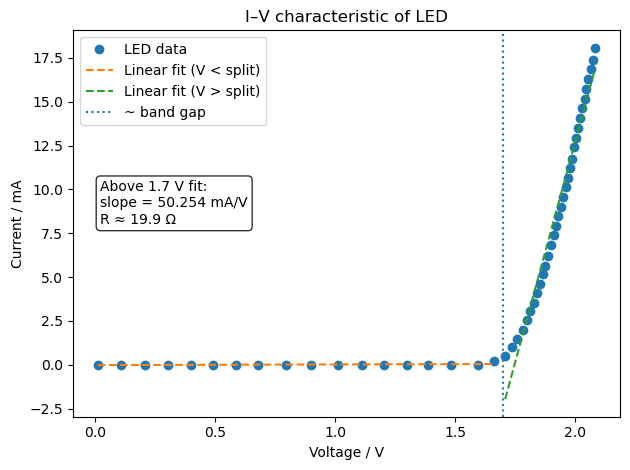

Data successfully saved to yellow_IV_repeat3.csv


(array([0.01 , 0.108, 0.205, 0.303, 0.4  , 0.491, 0.586, 0.677, 0.792,
        0.899, 1.012, 1.109, 1.203, 1.3  , 1.386, 1.482, 1.592, 1.659,
        1.707, 1.735, 1.757, 1.783, 1.796, 1.81 , 1.828, 1.841, 1.852,
        1.863, 1.874, 1.885, 1.9  , 1.91 , 1.92 , 1.929, 1.94 , 1.95 ,
        1.959, 1.967, 1.976, 1.985, 1.996, 2.003, 2.012, 2.019, 2.029,
        2.038, 2.046, 2.054, 2.063, 2.072, 2.082]),
 array([-1.0000e-03,  0.0000e+00,  0.0000e+00,  0.0000e+00,  3.0000e-03,
         1.0000e-03,  0.0000e+00, -1.0000e-03, -1.0000e-03,  0.0000e+00,
        -0.0000e+00, -1.0000e-03, -2.0000e-03, -3.0000e-03,  1.0000e-03,
         0.0000e+00,  0.0000e+00,  2.2200e-01,  4.9100e-01,  9.9500e-01,
         1.4930e+00,  1.9890e+00,  2.5270e+00,  3.0510e+00,  3.5440e+00,
         4.0730e+00,  4.6130e+00,  5.1530e+00,  5.6510e+00,  6.2140e+00,
         6.8470e+00,  7.3700e+00,  7.9060e+00,  8.4570e+00,  9.0100e+00,
         9.5400e+00,  1.0112e+01,  1.0651e+01,  1.1211e+01,  1.1734e+01,
         

In [8]:
run_color_led_iv_sweep(ser, 1.7, filename="yellow_IV_repeat3.csv")

In [60]:
def save_iv_csv(filename, V, I):
    """Save (V, I) arrays to CSV."""
    with open(filename, mode='w', newline='') as f:
        w = csv.writer(f)
        w.writerow(["Voltage (V)", "Current (mA)"])
        w.writerows(zip(V, I))
    print(f"Saved: {filename}")
    
def run_led_iv_sweep(
    ser,
    V_split,
    filename="led_IV.csv",
    v_start=0.0,
    v_stop=5.0,
    v_step=0.1,
    delay=0.1,
    Pn=200,
):
    """
    Sweep applied voltage, measure (V_LED, I), do 2 linear fits split by V_split,
    plot, and (optionally) save to CSV.
    Returns: V, I, (m_low, c_low), (m_high, c_high), R_high
    """

    # Set ADC averaging
    ser.write(f'<P{Pn}>'.encode())
    ser.readline()

    # Acquire data
    voltages, currents = [], []
    v_set = v_start
    while v_set <= v_stop + 1e-12:
        ser.write(f'<S{v_set:.2f}>'.encode())
        ser.readline()
        time.sleep(delay)

        ser.write(b'<V2>')
        V_meas = float(ser.readline().decode().split()[1])

        ser.write(b'<I1>')
        I_meas = float(ser.readline().decode().split()[1])

        voltages.append(V_meas)
        currents.append(I_meas)
        v_set += v_step

    V = np.array(voltages)
    I = np.array(currents)

    # Split & fit (guard against empty regions)
    low = V < V_split
    high = V > V_split

    if low.sum() < 2 or high.sum() < 2:
        raise ValueError(
            f"Not enough points for fitting. "
            f"Below split: {low.sum()}, above split: {high.sum()}. "
            f"Try a different V_split."
        )

    m_low, c_low = np.polyfit(V[low], I[low], 1)
    m_high, c_high = np.polyfit(V[high], I[high], 1)

    # I is in mA, so to compute ohm, we need to multiply by 1000.
    R_high = 1000 / m_high

    V_fit_low = np.linspace(V[low].min(), V[low].max(), 100)
    V_fit_high = np.linspace(V[high].min(), V[high].max(), 100)
    
    # Plot
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    plt.plot(V, I, 'o', label='Data')
    plt.plot(V_fit_low, m_low * V_fit_low + c_low, '--', label=f'Fit: V < {V_split}', linewidth=2.5)
    plt.plot(V_fit_high, m_high * V_fit_high + c_high, '--', label=f'Fit: V > {V_split}', linewidth=2.5)
    plt.axvline(V_split, linestyle=':', label='Split', color='grey', linewidth=2.5)

    plt.text(
        0.02, 0.6,
        f"Above {V_split:.2f} V:\n"
        f"slope = {m_high:.3f} mA/V\n"
        f"R ≈ {R_high:.3f} Ω",
        transform=plt.gca().transAxes,
        fontsize=14,
        fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    plt.xlabel('Voltage / V', fontsize=22, fontweight="bold")
    plt.ylabel('Current / mA', fontsize=22, fontweight="bold")
    plt.xticks(fontsize=14, fontweight='bold')
    plt.yticks(fontsize=14, fontweight='bold')
    plt.title('LED I–V characteristic', fontsize=20, fontweight="bold")
    leg = plt.legend(
    prop={'size': 12, 'weight': 'bold'},
    loc='upper left',
    frameon=True,
    fancybox=True
    )

    frame = leg.get_frame()
    frame.set_facecolor('white')
    frame.set_edgecolor('black')
    frame.set_linewidth(1.2)
    frame.set_alpha(0.85)

    plt.tight_layout()
    plt.show()

    # ---- CSV save toggle (comment/uncomment ONE line) ----
    #save_iv_csv(filename, V, I)  # <--- comment this ONE line to disable saving
    # -----------------------------------------------------
    #print(f"Resistance after turn-on voltage is {R_high:.3f} Ω")
    return 

In [61]:
run_led_iv_sweep(ser, 1.7, filename="white_IV.csv1.csv")

IndexError: list index out of range